In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:

# Load the primary datasets
prevalence_df = pd.read_csv('data/1- mental-illnesses-prevalence.csv')
burden_df = pd.read_csv('data/2- burden-disease-from-each-mental-illness(1).csv')
treatment_df = pd.read_csv('data/5- anxiety-disorders-treatment-gap.csv')
symptoms_df = pd.read_csv('data/6- depressive-symptoms-across-us-population.csv')

# Rename complex columns for cleaner SQL-like analysis
prevalence_df.columns = ['entity', 'code', 'year', 'schiz', 'depressive', 'anxiety', 'bipolar', 'eating']
burden_df.columns = ['entity', 'code', 'year', 'daly_depressive', 'daly_schiz', 'daly_bipolar', 'daly_eating', 'daly_anxiety']
treatment_df.columns = ['entity', 'code', 'year', 'adequate_treatment', 'other_treatment', 'untreated']
us_symptoms.columns = ['entity', 'code', 'year', 'every_day', 'more_half_days', 'several_days', 'not_at_all']

# Drop rows where 'code' is null (usually regional aggregates rather than specific countries)
prevalence_clean = prevalence_df.dropna(subset=['code'])
burden_clean = burden_df.dropna(subset=['code'])

symptoms_sorted = us_symptoms.sort_values('every_day', ascending=False)


In [4]:

# Merge Prevalence and Burden data on Entity and Year
merged_df = pd.merge(prevalence_clean, burden_clean, on=['entity', 'code', 'year'])

# Calculate the Burden Intensity Ratio (DALYs per percentage of prevalence)
merged_df['depression_burden_ratio'] = merged_df['daly_depressive'] / merged_df['depressive']


C:\Users\Professional\AppData\Local\Temp\ipykernel_7344\3023757922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_depression, x='depressive', y='entity', palette='Reds_r')


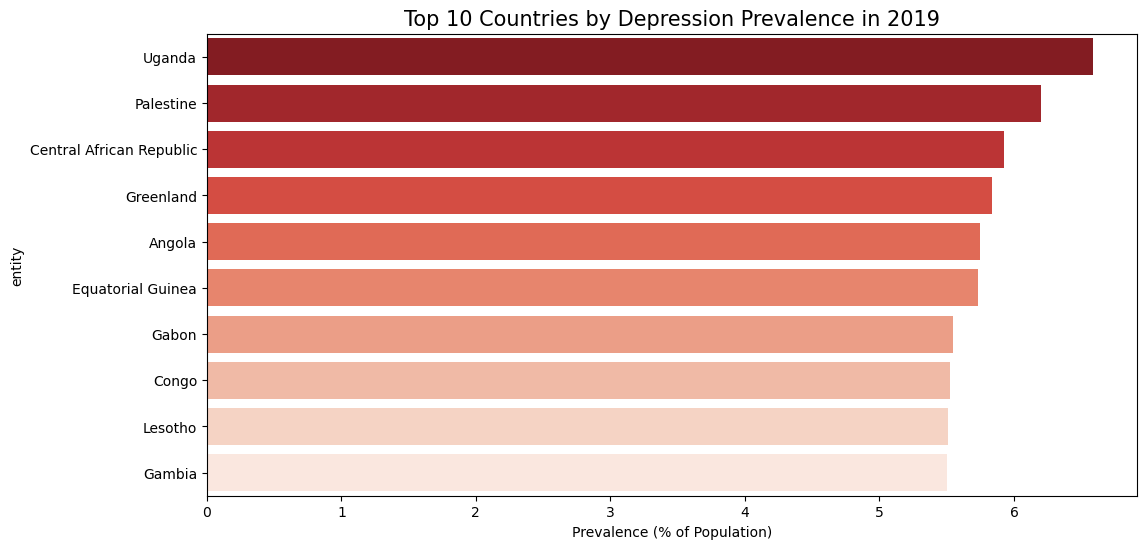

In [6]:

# ### 1 Top 10 Countries by Depression Prevalence (Latest Year)

latest_year = merged_df['year'].max()
top_depression = merged_df[merged_df['year'] == latest_year].sort_values('depressive', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_depression, x='depressive', y='entity', palette='Reds_r')
plt.title(f'Top 10 Countries by Depression Prevalence in {latest_year}', fontsize=15)
plt.xlabel('Prevalence (% of Population)')
plt.savefig('visuals/depression_prevalence_top10.png', dpi=300, bbox_inches='tight')
plt.show()


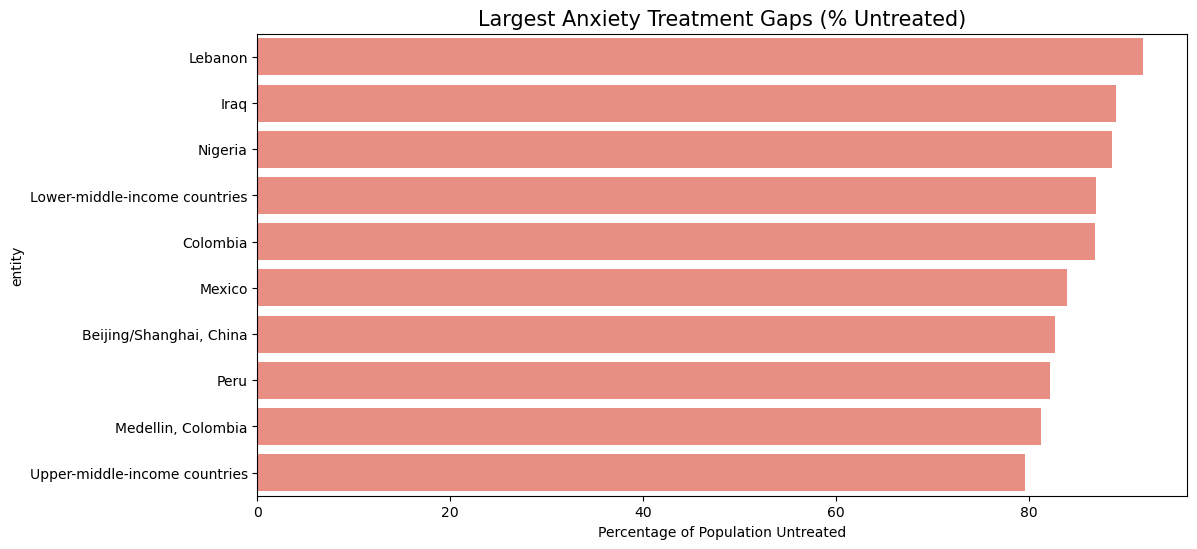

In [8]:

# ### 2 The Treatment Gap for Anxiety

top_untreated = treatment_df.sort_values('untreated', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_untreated, x='untreated', y='entity', color='salmon')
plt.title('Largest Anxiety Treatment Gaps (% Untreated)', fontsize=15)
plt.xlabel('Percentage of Population Untreated')
plt.savefig('visuals/anxiety_treatment_gap.png', dpi=300, bbox_inches='tight')
plt.show()


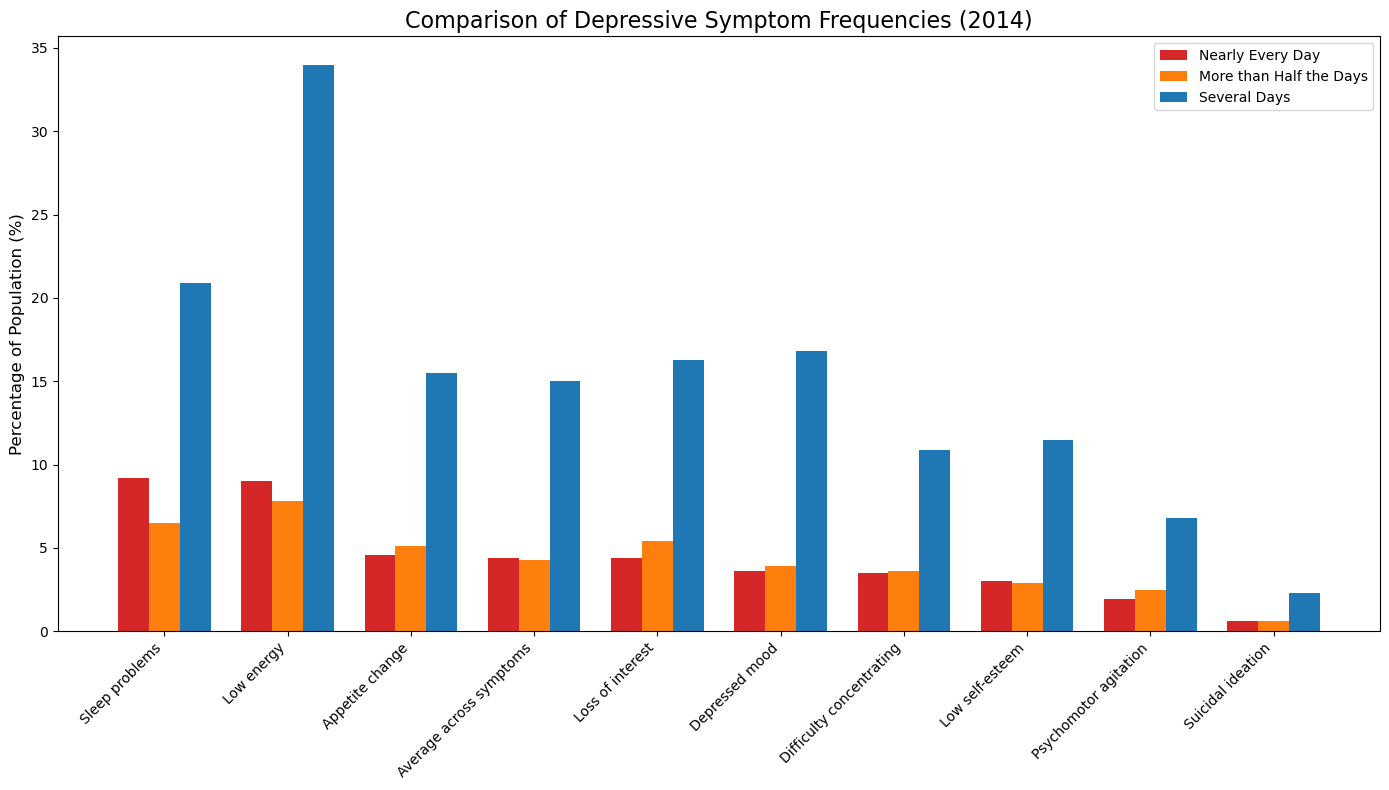

In [19]:
# Plotting Setup
labels = symptoms_sorted['entity']
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

# Create Grouped Bars
ax.bar(x - width, symptoms_sorted['every_day'], width, label='Nearly Every Day', color='#d62728')
ax.bar(x, symptoms_sorted['more_half_days'], width, label='More than Half the Days', color='#ff7f0e')
ax.bar(x + width, symptoms_sorted['several_days'], width, label='Several Days', color='#1f77b4')

# Formatting
ax.set_ylabel('Percentage of Population (%)', fontsize=12)

# Grab the year value (assumes data is present)
current_year = symptoms_sorted['year'].values[0]
ax.set_title(f'Comparison of Depressive Symptom Frequencies ({current_year})', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.legend()

plt.tight_layout()

# Save and Show
plt.savefig('visuals/us_symptoms_comparison.png', dpi=300)
plt.show()